========== 1. Loading Iris dataset ==========

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

    class  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset shape: (150, 5)

Class distribution:
class
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

========== 2. Pairplot Visualization ==========


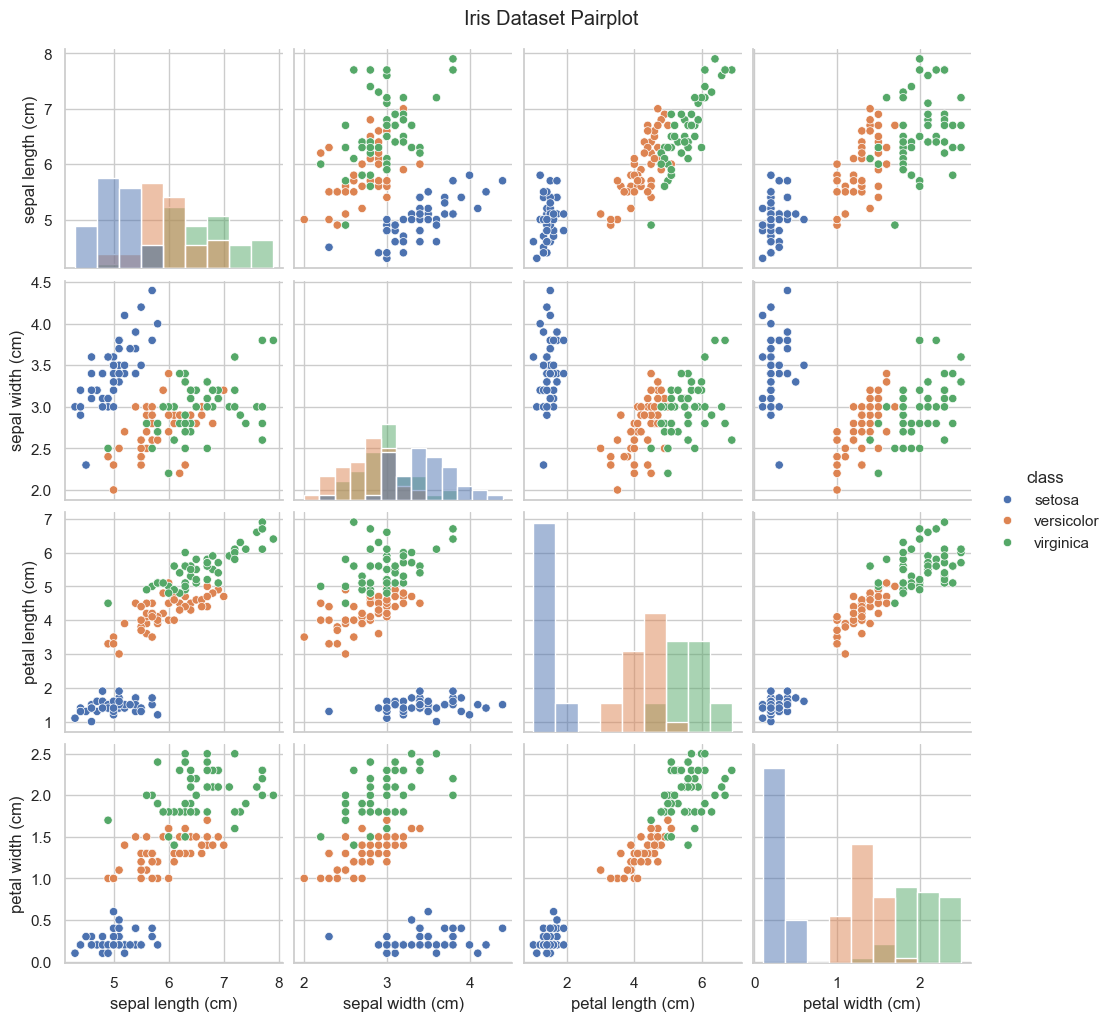


========== 3. Logistic Regression Binary Classification ==========
Training samples: 80
Testing samples: 20

Accuracy: 0.9

Confusion Matrix:
[[10  0]
 [ 2  8]]

Classification Report:
              precision    recall  f1-score   support

  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



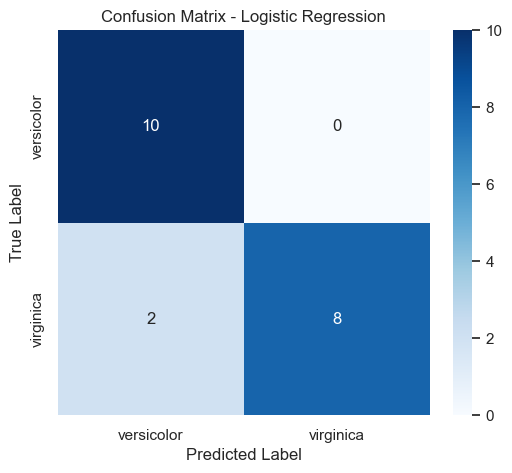


========== 4. Generate Regression Data ==========
Regression training samples: 35
Regression testing samples: 15


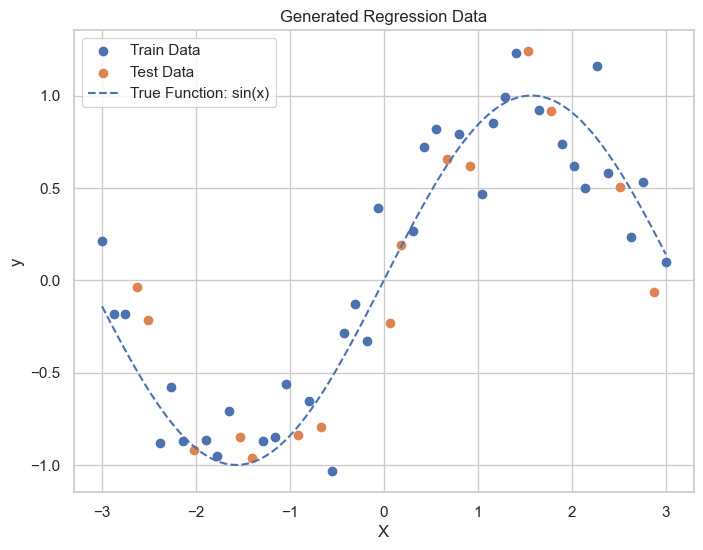


========== Underfitting ==========
Polynomial Degree: 1
Train MSE: 0.230002
Test  MSE: 0.279905
Train R2 : 0.527006
Test  R2 : 0.429983


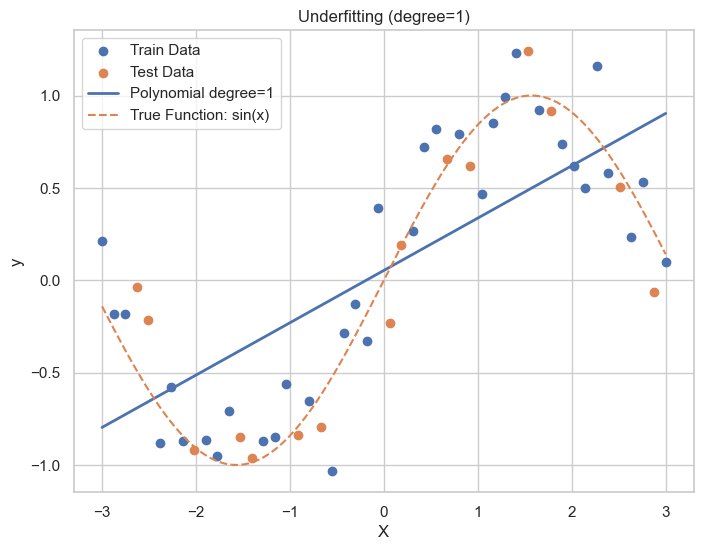


========== Good Fit ==========
Polynomial Degree: 4
Train MSE: 0.049411
Test  MSE: 0.052181
Train R2 : 0.898388
Test  R2 : 0.893736


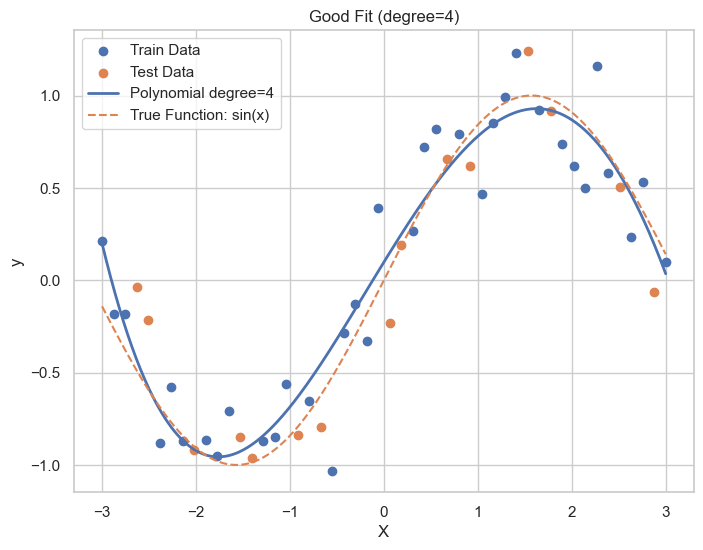


========== Overfitting ==========
Polynomial Degree: 15
Train MSE: 0.030512
Test  MSE: 0.183371
Train R2 : 0.937252
Test  R2 : 0.626570


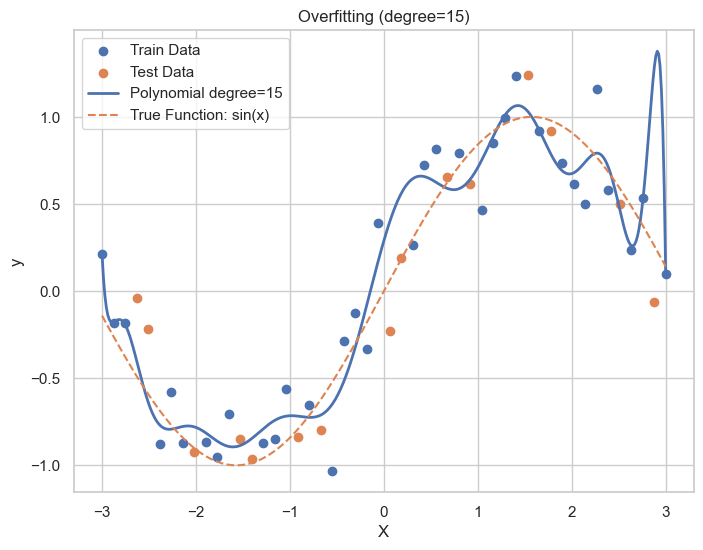


========== 5. Summary of Three Fitting Cases ==========
     Model Type  Degree  Train MSE  Test MSE  Train R2   Test R2
0  Underfitting       1   0.230002  0.279905  0.527006  0.429983
1      Good Fit       4   0.049411  0.052181  0.898388  0.893736
2   Overfitting      15   0.030512  0.183371  0.937252  0.626570

========== 6. Combined Comparison Figure ==========


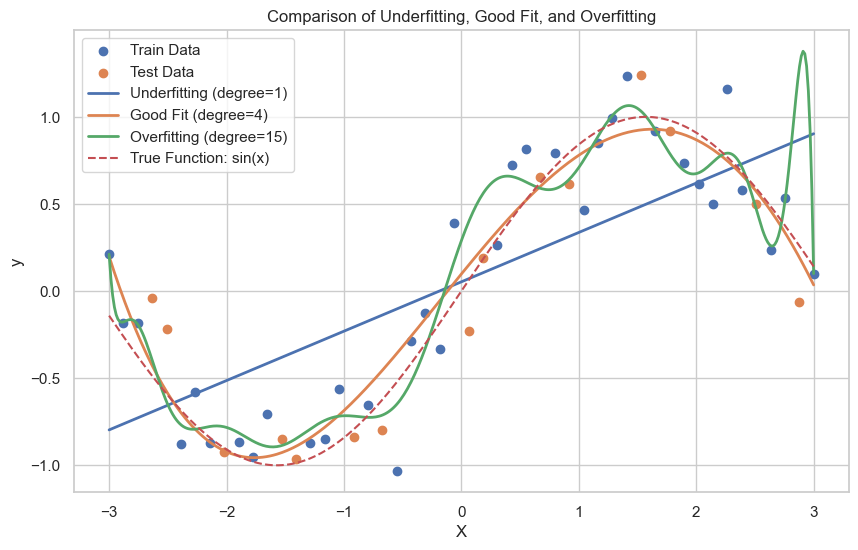


========== 7. Model Complexity vs Error ==========


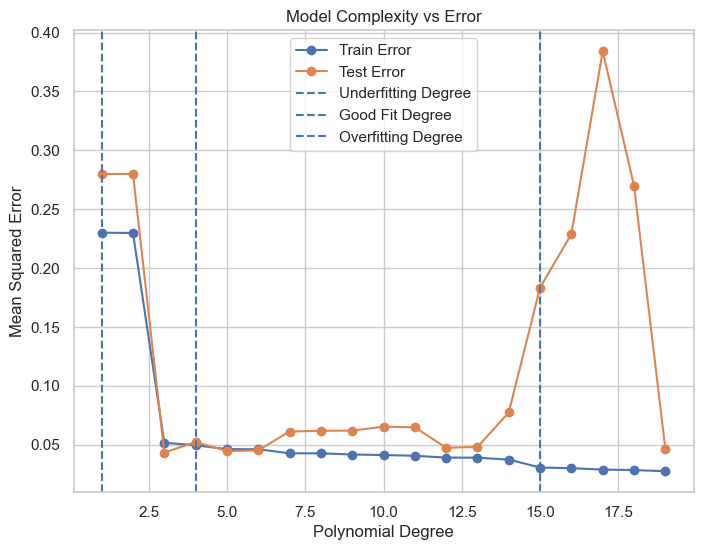


========== 8. Final Conclusion ==========
1. 使用 sklearn 自带 Iris 数据集完成了数据加载与可视化分析。
2. pairplot 显示不同类别在多个特征上存在明显分布差异。
3. 使用 Logistic Regression 对 versicolor 和 virginica 进行二分类，完成了分类实验。
4. 在多项式回归实验中：
   - degree=1 表现为欠拟合，模型过于简单；
   - degree=4 表现为合适拟合，训练集和测试集效果较平衡；
   - degree=15 表现为过拟合，训练误差很低，但测试误差明显增大。
5. 通过模型复杂度与误差曲线，可以直观看出复杂度增加并不一定带来更好的泛化能力。

========== Experiment Finished ==========


In [1]:
# ==========================================
# Lab1 - Machine Learning Basics
# Using sklearn built-in Iris dataset
# 完整版：包含欠拟合、合适拟合、过拟合，并分别输出结果图
# ==========================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# 图像风格
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

# ==========================================
# 1. Load Iris dataset
# ==========================================
print("========== 1. Loading Iris dataset ==========")

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["class"] = iris.target
df["class"] = df["class"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)

print("\nClass distribution:")
print(df["class"].value_counts())

# ==========================================
# 2. Pairplot Visualization
# ==========================================
print("\n========== 2. Pairplot Visualization ==========")

sns.pairplot(df, hue="class", diag_kind="hist")
plt.suptitle("Iris Dataset Pairplot", y=1.02)
plt.show()

# ==========================================
# 3. Logistic Regression Binary Classification
# 选取更有区分难度的 versicolor 和 virginica
# ==========================================
print("\n========== 3. Logistic Regression Binary Classification ==========")

binary_df = df[df["class"].isin(["versicolor", "virginica"])].copy()

binary_df["target"] = binary_df["class"].map({
    "versicolor": 0,
    "virginica": 1
})

X_clf = binary_df[iris.feature_names]
y_clf = binary_df["target"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Training samples:", len(X_train_clf))
print("Testing samples:", len(X_test_clf))

clf_model = LogisticRegression(max_iter=200)
clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)

print("\nAccuracy:", accuracy_score(y_test_clf, y_pred_clf))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_clf, y_pred_clf)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=["versicolor", "virginica"]))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["versicolor", "virginica"],
    yticklabels=["versicolor", "virginica"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ==========================================
# 4. Generate Regression Data for Fitting Demo
# 使用带噪声的 sin 曲线来展示拟合情况
# ==========================================
print("\n========== 4. Generate Regression Data ==========")

np.random.seed(0)

X_reg = np.linspace(-3, 3, 50)
y_reg = np.sin(X_reg) + np.random.normal(0, 0.2, 50)

X_reg = X_reg.reshape(-1, 1)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=42
)

print("Regression training samples:", len(X_train_reg))
print("Regression testing samples:", len(X_test_reg))

# 画原始数据
plt.figure(figsize=(8, 6))
plt.scatter(X_train_reg, y_train_reg, label="Train Data")
plt.scatter(X_test_reg, y_test_reg, label="Test Data")
plt.plot(np.linspace(-3, 3, 300), np.sin(np.linspace(-3, 3, 300)), linestyle="--", label="True Function: sin(x)")
plt.title("Generated Regression Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# ==========================================
# 5. Define Function for Model Training + Plot
# ==========================================
def fit_and_plot_model(degree, title_text):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])
    
    model.fit(X_train_reg, y_train_reg)
    
    y_train_pred = model.predict(X_train_reg)
    y_test_pred = model.predict(X_test_reg)
    
    train_mse = mean_squared_error(y_train_reg, y_train_pred)
    test_mse = mean_squared_error(y_test_reg, y_test_pred)
    train_r2 = r2_score(y_train_reg, y_train_pred)
    test_r2 = r2_score(y_test_reg, y_test_pred)
    
    X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    
    print(f"\n========== {title_text} ==========")
    print(f"Polynomial Degree: {degree}")
    print(f"Train MSE: {train_mse:.6f}")
    print(f"Test  MSE: {test_mse:.6f}")
    print(f"Train R2 : {train_r2:.6f}")
    print(f"Test  R2 : {test_r2:.6f}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_reg, y_train_reg, label="Train Data")
    plt.scatter(X_test_reg, y_test_reg, label="Test Data")
    plt.plot(X_plot, y_plot, linewidth=2, label=f"Polynomial degree={degree}")
    plt.plot(np.linspace(-3, 3, 400), np.sin(np.linspace(-3, 3, 400)), linestyle="--", label="True Function: sin(x)")
    plt.title(f"{title_text} (degree={degree})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()
    
    return {
        "Model Type": title_text,
        "Degree": degree,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Model": model
    }

# ==========================================
# 6. Show Underfitting / Good Fit / Overfitting
# degree=1   -> 欠拟合
# degree=4   -> 合适拟合
# degree=15  -> 过拟合
# ==========================================
underfit_result = fit_and_plot_model(1, "Underfitting")
goodfit_result  = fit_and_plot_model(4, "Good Fit")
overfit_result  = fit_and_plot_model(15, "Overfitting")

# ==========================================
# 7. Summary Table
# ==========================================
print("\n========== 5. Summary of Three Fitting Cases ==========")

summary_df = pd.DataFrame([
    {
        "Model Type": underfit_result["Model Type"],
        "Degree": underfit_result["Degree"],
        "Train MSE": underfit_result["Train MSE"],
        "Test MSE": underfit_result["Test MSE"],
        "Train R2": underfit_result["Train R2"],
        "Test R2": underfit_result["Test R2"]
    },
    {
        "Model Type": goodfit_result["Model Type"],
        "Degree": goodfit_result["Degree"],
        "Train MSE": goodfit_result["Train MSE"],
        "Test MSE": goodfit_result["Test MSE"],
        "Train R2": goodfit_result["Train R2"],
        "Test R2": goodfit_result["Test R2"]
    },
    {
        "Model Type": overfit_result["Model Type"],
        "Degree": overfit_result["Degree"],
        "Train MSE": overfit_result["Train MSE"],
        "Test MSE": overfit_result["Test MSE"],
        "Train R2": overfit_result["Train R2"],
        "Test R2": overfit_result["Test R2"]
    }
])

print(summary_df)

# ==========================================
# 8. Combined Comparison Figure
# 一张图对比三种拟合情况
# ==========================================
print("\n========== 6. Combined Comparison Figure ==========")

X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

y_underfit = underfit_result["Model"].predict(X_plot)
y_goodfit  = goodfit_result["Model"].predict(X_plot)
y_overfit  = overfit_result["Model"].predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_reg, y_train_reg, label="Train Data")
plt.scatter(X_test_reg, y_test_reg, label="Test Data")
plt.plot(X_plot, y_underfit, linewidth=2, label="Underfitting (degree=1)")
plt.plot(X_plot, y_goodfit, linewidth=2, label="Good Fit (degree=4)")
plt.plot(X_plot, y_overfit, linewidth=2, label="Overfitting (degree=15)")
plt.plot(np.linspace(-3, 3, 400), np.sin(np.linspace(-3, 3, 400)), linestyle="--", label="True Function: sin(x)")
plt.title("Comparison of Underfitting, Good Fit, and Overfitting")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# ==========================================
# 9. Error Curve: Model Complexity vs Error
# ==========================================
print("\n========== 7. Model Complexity vs Error ==========")

degrees = range(1, 20)
train_errors = []
test_errors = []

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("linear", LinearRegression())
    ])
    
    model.fit(X_train_reg, y_train_reg)
    
    y_train_pred = model.predict(X_train_reg)
    y_test_pred = model.predict(X_test_reg)
    
    train_errors.append(mean_squared_error(y_train_reg, y_train_pred))
    test_errors.append(mean_squared_error(y_test_reg, y_test_pred))

plt.figure(figsize=(8, 6))
plt.plot(degrees, train_errors, marker="o", label="Train Error")
plt.plot(degrees, test_errors, marker="o", label="Test Error")
plt.axvline(x=1, linestyle="--", label="Underfitting Degree")
plt.axvline(x=4, linestyle="--", label="Good Fit Degree")
plt.axvline(x=15, linestyle="--", label="Overfitting Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Complexity vs Error")
plt.legend()
plt.show()

# ==========================================
# 10. Final Conclusion
# ==========================================
print("\n========== 8. Final Conclusion ==========")
print(
    "1. 使用 sklearn 自带 Iris 数据集完成了数据加载与可视化分析。\n"
    "2. pairplot 显示不同类别在多个特征上存在明显分布差异。\n"
    "3. 使用 Logistic Regression 对 versicolor 和 virginica 进行二分类，完成了分类实验。\n"
    "4. 在多项式回归实验中：\n"
    "   - degree=1 表现为欠拟合，模型过于简单；\n"
    "   - degree=4 表现为合适拟合，训练集和测试集效果较平衡；\n"
    "   - degree=15 表现为过拟合，训练误差很低，但测试误差明显增大。\n"
    "5. 通过模型复杂度与误差曲线，可以直观看出复杂度增加并不一定带来更好的泛化能力。"
)

print("\n========== Experiment Finished ==========")